## Name: Reem Alyahya

# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [61]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [62]:
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv")
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [63]:
x = df['Experience Years']
y = df['Salary']

### Step 2.b print the type of each

In [64]:
x.dtype, y.dtype

(dtype('float64'), dtype('int64'))

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

**The target is Numerical and thee task is regression.**

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [65]:
print(f'data matrix:{x.shape}')
print(f'target:{y.shape}')

data matrix:(40,)
target:(40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [66]:
df.agg(['min','max','median','mean','std'])

,Experience Years,Salary
min,1.100000,37731.000000
max,10.500000,122391.000000
median,4.600000,64472.500000
mean,5.152500,74743.625000
std,2.663715,25947.122885


### Step 5. Plot the feature vs the target

<Axes: xlabel='Experience Years', ylabel='Salary'>

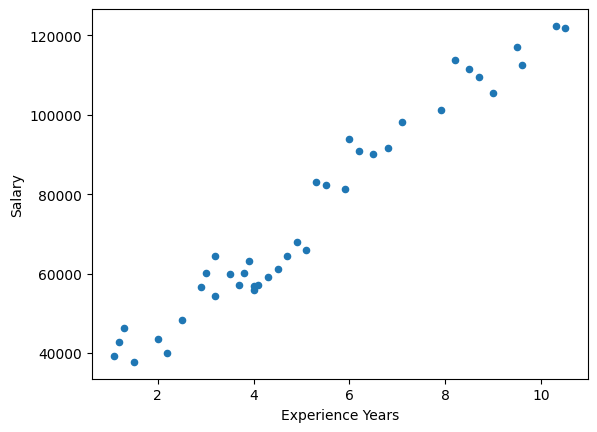

In [67]:
df.plot.scatter(
    x = 'Experience Years',
    y = 'Salary'
)

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

**Increasing**

### Step 7. Initialize a regression model

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [69]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42,
)

### Step 9.a Train the model on the training set

In [70]:
model.fit(x_train.to_frame(), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [71]:
slope = model.coef_[0].round(2)
intercept = model.intercept_.round(2)

print(f'slope = {slope}\nintercept = {intercept}')

slope = 9408.03
intercept = 26716.25


### Step 9.c how much salary does a person get with 2 years of experience?

In [72]:
print(intercept+(slope * 2))

45532.31


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [73]:
print(slope * 0.5)

4704.015


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [74]:
print(intercept)

26716.25


### Step 10. Evaluate the model on the test set

In [75]:
y_predict = model.predict(x_test.to_frame())

In [77]:
from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(y_test, y_predict)
print(f'mean absolute error:{error}')

mean absolute error:6419.911069460598


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [78]:
compared = pd.DataFrame(
    {
        'Actual Result': y_test.head(3),
        'Predicted': y_predict[:3]
    }
)
compared

,Actual Result,Predicted
19,61111,69052.390902
16,56957,64348.375266
15,55794,64348.375266


### Step 12. Plot the data and the regression line

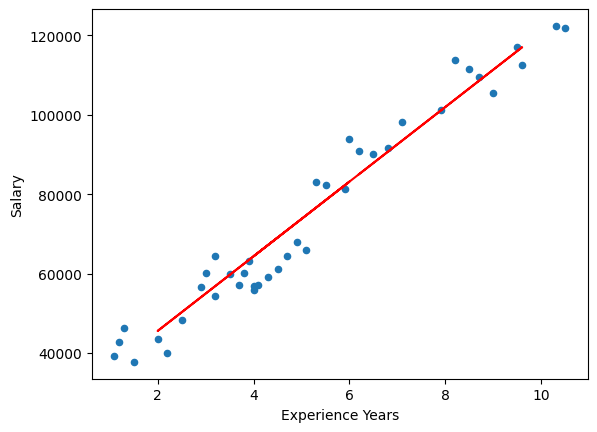

In [79]:
fig = df.plot.scatter(
    x = 'Experience Years',
    y = 'Salary'
)
fig.plot(x_test, y_predict, color = 'red')